# Polynomial Regression from Scratch

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Mock Data Generation

In [2]:
def generate_nonlinear_data(n_samples=150):
    X = np.random.rand(n_samples, 4) * 2 - 1 # Features between -1 and 1
    
    y = 2*(X[:, 0]**2) - 3*X[:, 1] + 0.5*(X[:, 2]*X[:, 3]) + 1.0 + np.random.normal(0, 0.9, n_samples)
    
    columns = [f"Feature_{i+1}" for i in range(4)]
    df = pd.DataFrame(X, columns=columns)
    df['Target'] = y
    return df, X, y

df, X, y = generate_nonlinear_data()
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Target
0,0.736312,0.181714,0.923638,0.062661,1.068694
1,0.301587,-0.882238,0.806400,0.786385,4.290757
2,-0.806788,-0.968271,-0.568433,-0.669181,6.182880
3,-0.071345,-0.120612,0.579116,-0.611173,1.136275
4,-0.616228,0.232769,-0.459671,-0.536563,1.102786


## 2. Polynomial Feature Transformation

We need to transform $[x_1, x_2, ...]$ into $[1, x_1, x_2, x_1^2, x_1x_2, ...]$.

In [3]:
def get_poly_features(X, degree):
    import numpy as np
    from itertools import combinations_with_replacement
    
    n_samples, n_features = X.shape
    out = [np.ones(n_samples)]  # Bias term (degree 0)

    for d in range(1, degree + 1):
        for comb in combinations_with_replacement(range(n_features), d):
            feature = np.ones(n_samples)
            for i in comb:
                feature *= X[:, i]
            out.append(feature)

    return np.array(out).T

## 3. Training the Model using Gradient Descent

In [ ]:
class PolynomialRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)

        for _ in range(self.n_iterations):
            y_pred = np.dot(X, self.weights)
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            self.weights -= self.lr * dw
            cost = (1/(2*n_samples)) * np.sum((y_pred - y)**2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.dot(X, self.weights)

X_poly = get_poly_features(X, degree=3)
model = PolynomialRegressionGD(learning_rate=0.1, n_iterations=5000)
model.fit(X_poly, y)

print(f"Transformed features count: {X_poly.shape[1]}")
print(f"Final Cost: {model.cost_history[-1]}")

(150, 35)
Transformed features count: 35
Final Cost: 0.24564744207412517


## 4. Visualization of Results

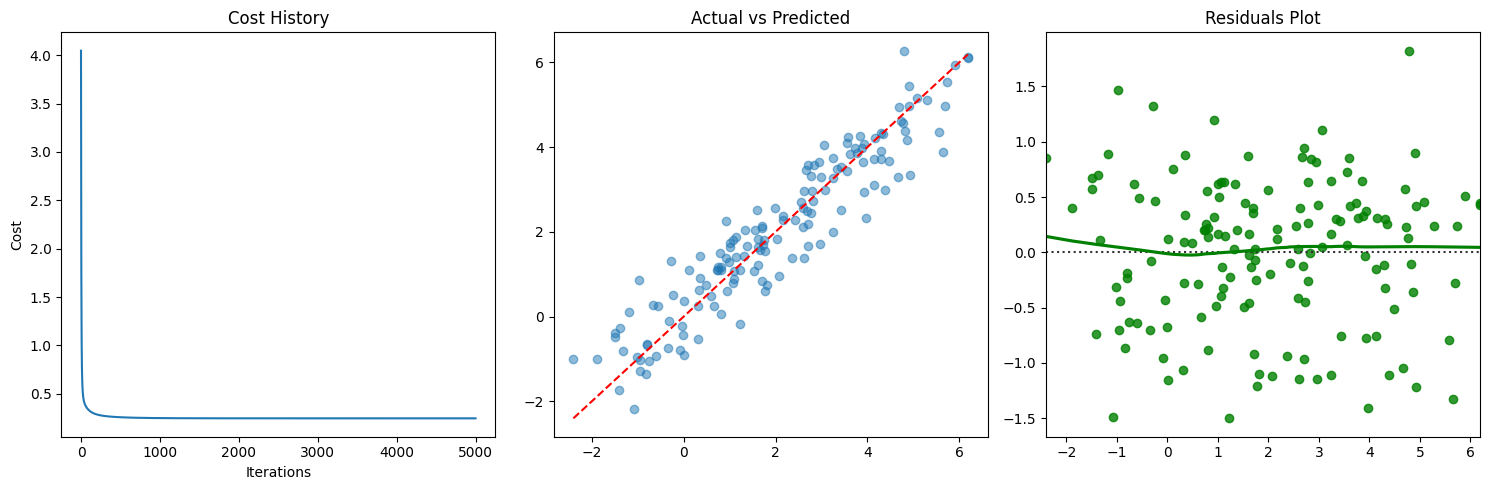

In [5]:
y_pred = model.predict(X_poly)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(model.cost_history)
plt.title("Cost History")
plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.subplot(1, 3, 2)
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Actual vs Predicted")

plt.subplot(1, 3, 3)
sns.residplot(x=y, y=y_pred, lowess=True, color="g")
plt.title("Residuals Plot")

plt.tight_layout()
plt.show()